In [2]:
# Importing the libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Importing the dataset
from pathlib import Path


data_path = Path('data/raw/Customer_churn.csv')
if not data_path.exists():
    data_path = Path('../data/raw/Customer_churn.csv')

df = pd.read_csv(data_path)

In [8]:
# Checking the shape of the dataset
print(f"The dataset has {df.shape[0]} rows and {df.shape[1]}")

The dataset has 7043 rows and 21


In [9]:
# Checking the first 5 rows of the dataset
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
# Fixing TotalCharges
print("Before conversion:")
print(df["TotalCharges"].dtype)

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)
print("\nAfter conversion:")
print(df["TotalCharges"].dtype)

print("\nMissing values created by conversion:")
print(df["TotalCharges"].isna().sum())

Before conversion:
float64

After conversion:
float64

Missing values created by conversion:
11


In [ ]:
# Showing rows where TotalCharges could not be converted
invalid_totalcharges = df[df["TotalCharges"].isna()]

print("Rows with missing TotalCharges:")
display(invalid_totalcharges)

Rows with missing TotalCharges:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [7]:
missing_summary = (
    df.isna()
      .sum()
      .reset_index()
)

missing_summary.columns = [
    "Column",
    "Missing_Count"
]

missing_summary["Missing_Percentage"] = (
    missing_summary["Missing_Count"] /
    len(df) * 100
)

missing_summary = (
    missing_summary
    .sort_values("Missing_Count", ascending=False)
)

display(missing_summary)

,Column,Missing_Count,Missing_Percentage
19,TotalCharges,11,0.156183
1,gender,0,0.000000
2,SeniorCitizen,0,0.000000
3,Partner,0,0.000000
0,customerID,0,0.000000
4,Dependents,0,0.000000
5,tenure,0,0.000000
7,MultipleLines,0,0.000000
6,PhoneService,0,0.000000
9,OnlineSecurity,0,0.000000


In [8]:
# Analysing duplicates
duplicate_rows = df.duplicated().sum()
duplicate_customer_ids = df["customerID"].duplicated().sum()

print("Duplicate rows:", duplicate_rows)
print("Duplicate customer IDs:", duplicate_customer_ids)

Duplicate rows: 0
Duplicate customer IDs: 0


Churn
No     5174
Yes    1869
Name: count, dtype: int64


NameError: name 'reports' is not defined

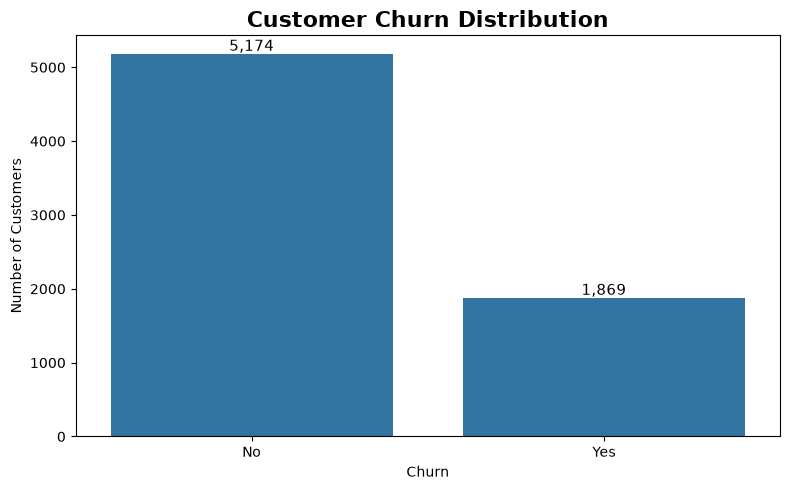

In [ ]:
# Churn Distribution Bar Chart

churn_counts = df["Churn"].value_counts()

print(churn_counts)

fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    x=churn_counts.index,
    y=churn_counts.values,
    ax=ax
)

ax.set_title(
    "Customer Churn Distribution",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Churn")
ax.set_ylabel("Number of Customers")

for i, value in enumerate(churn_counts.values):
    ax.text(
        i,
        value + 50,
        f"{value:,}",
        ha="center",
        fontsize=11
    )

reports_dir = Path("reports")
if not reports_dir.exists() and Path("../reports").exists():
    reports_dir = Path("../reports")
reports_dir.mkdir(parents=True, exist_ok=True)

plt.tight_layout()
plt.savefig(
    reports_dir / "01_churn_distribution_bar.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()